In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return np.sin(np.pi * x / 2)

def g(x):
    return x


In [4]:

def fractalize(f, g, partition, alpha, n_points=2000, n_iter=50):


    partition = np.asarray(partition, dtype=float)

    a = partition[0]
    b = partition[-1]

    N = len(partition) - 1

    if np.isscalar(alpha):
        alpha = np.full(N, alpha, dtype=float)
    else:
        alpha = np.asarray(alpha, dtype=float)

    if len(alpha) != N:
        raise ValueError("Length of alpha must be equal to len(partition) - 1.")

    if np.any(np.abs(alpha) >= 1):
        raise ValueError("All alpha values must satisfy |alpha_i| < 1.")

    x = np.linspace(a, b, n_points)

    fx = f(x)

    # Initial guess
    y = fx.copy()

    for _ in range(n_iter):
        y_new = fx.copy()

        for i in range(N):
            x_left = partition[i]
            x_right = partition[i + 1]

            if i < N - 1:
                mask = (x >= x_left) & (x < x_right)
            else:
                mask = (x >= x_left) & (x <= x_right)

            # L_i maps [a,b] -> [x_left,x_right]
            # So L_i^{-1}(x) is:
            u = a + (x[mask] - x_left) * (b - a) / (x_right - x_left)

            # Approximate f^alpha(L_i^{-1}(x)) using interpolation
            y_u = np.interp(u, x, y)

            y_new[mask] = f(x[mask]) + alpha[i] * (y_u - g(u))

        y = y_new

    return x, fx, y






In [12]:
# --------------------------------------------------
# 3. Choose partition and alpha values
# --------------------------------------------------




# partition = [0, 0.5, 1]
X =np.linspace(0, 1, 3)

# Same alpha on each subinterval
alpha = 0.4

# Alternatively, use different alpha values:
# alpha = [0.4, -0.3]



In [ ]:

# --------------------------------------------------
# 4. Compute f(x) and f^alpha(x)
# --------------------------------------------------

x, fx, f_alpha = fractalize(f, g, X, alpha, 3000, 80)


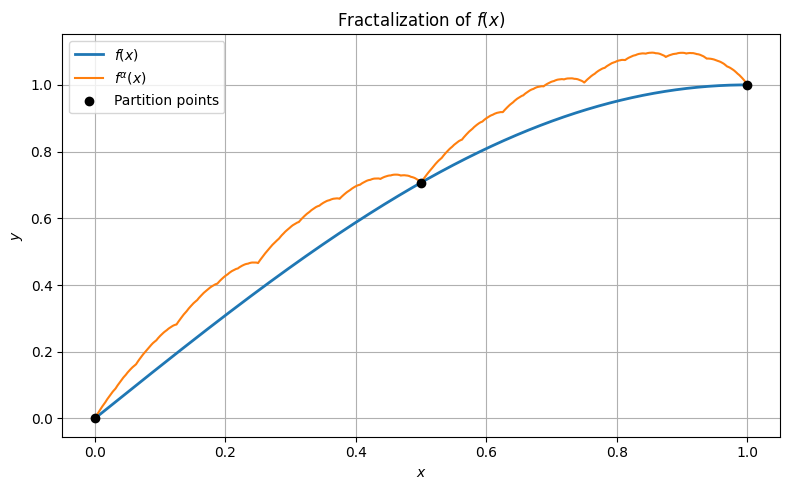

In [14]:
# --------------------------------------------------
# 5. Plot
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(x, fx, label=r"$f(x)$", linewidth=2)
plt.plot(x, f_alpha, label=r"$f^\alpha(x)$", linewidth=1.5)

plt.scatter(X, f(np.array(X)), color="black", zorder=5, label="Partition points")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Fractalization of $f(x)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()